# Backend comparison: NeuroKit2 vs biosignalsnotebooks

**Goal.**  raw biosignals using the procedures illustrated in [biosignalsnotebooks](https://github.com/pluxbiosignals/biosignalsnotebooks). This notebook runs both extraction backends on the **same** raw OpenSignals recording and overlays the results so the two approaches can be compared on a single page.

**Backends compared:**

| | NeuroKit2 (current) | biosignalsnotebooks (prof) |
|---|---|---|
| ECG cleaning   | `nk.ecg_clean` (FIR 0.5 Hz HP + 50 Hz notch) | Pan-Tompkins internal (BP 5-15 Hz + diff + square + integrate) |
| R-peak detect  | `nk.ecg_peaks(correct_artifacts=True)` (Kubios) | `detect.detect_r_peaks` (Pan-Tompkins / Selvaraj) |
| HR            | `nk.ecg_rate(...)` mean over window | `60 / mean(diff(R-peaks) / fs)` |
| RMSSD          | `nk.hrv_time(...)['HRV_RMSSD']` + Malik 20 % gate | `sqrt(mean(diff(RR)^2))` + Malik 20 % gate |
| EDA phasic     | `nk.eda_phasic` (cvxEDA decomposition) | `eda - lowpass(eda, 0.05 Hz)` |

**Fusion math (stress index) is unchanged** in both arms — it consumes whichever HR / HRV / EDA stream you point it at.

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Make src/ importable
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

from data_sources import (parse_opensignals_header,
                          adc_to_eda_uS, adc_to_ecg_mV,
                          _pre_derive_hr_hrv_neurokit)
from bsnb_backend import pre_derive_hr_hrv_bsnb, decompose_eda_bsnb

# NeuroKit2 phasic EDA helper (we replicate the offline call here
# instead of going through processing.SignalProcessor, which is
# online-only)
import neurokit2 as nk

print('Backends loaded.')

Backends loaded.


## 1. Load a raw OpenSignals recording

Pick any `.txt` file in `data/` (or under `data/real1/`). The notebook will:
1. Parse the OpenSignals JSON header for sampling rate and channel order
2. Convert raw ADC -> physical units (uS, mV) via the documented PLUX transfer functions
3. Run both backends to derive HR / HRV / EDA series

In [2]:
# === EDIT THIS LINE TO PICK A DIFFERENT FILE ===
FILE_PATH = 'data/real1/opensignals_0007800F319C_2026-06-04_16-02-23.txt'

header = parse_opensignals_header(FILE_PATH)
fs = header['fs_hz']
col_eda = header['column_index']['EDA']
col_ecg = header['column_index']['ECG']
n_cols = len(header['columns'])
data = np.genfromtxt(FILE_PATH, skip_header=3,
                     usecols=tuple(range(n_cols)),
                     invalid_raise=False)
data = data[np.all(np.isfinite(data), axis=1)]
eda_uS = adc_to_eda_uS(data[:, col_eda])
ecg_mV = adc_to_ecg_mV(data[:, col_ecg])
n = len(eda_uS)
t  = np.arange(n) / fs

print(f'File:     {os.path.basename(FILE_PATH)}')
print(f'fs:       {fs:.0f} Hz')
print(f'duration: {t[-1]:.1f} s  ({n} samples)')
print(f'EDA col:  {col_eda},  mean = {eda_uS.mean():.2f} uS')
print(f'ECG col:  {col_ecg},  mean = {ecg_mV.mean():+.4f} mV,  '
      f'p-p = {ecg_mV.max() - ecg_mV.min():.3f} mV')

File:     opensignals_0007800F319C_2026-06-04_16-02-23.txt
fs:       200 Hz
duration: 776.5 s  (155310 samples)
EDA col:  2,  mean = 5.20 uS
ECG col:  3,  mean = -0.0021 mV,  p-p = 2.154 mV


## 2. Run BOTH backends
Each call replays the streaming windowing the live pipeline uses (HR over 30 s trailing, RMSSD over 60 s trailing, recompute every 0.5 s, ZOH between recomputes).

In [3]:
t0 = time.time()
hr_nk, hrv_nk = _pre_derive_hr_hrv_neurokit(ecg_mV, fs)
print(f'NeuroKit2 backend: {time.time() - t0:.1f} s')

t0 = time.time()
hr_bs, hrv_bs = pre_derive_hr_hrv_bsnb(ecg_mV, fs)
print(f'biosignalsnotebooks backend: {time.time() - t0:.1f} s')

def _stats(s, label):
    valid = np.isfinite(s)
    return (f'{label:10s}  valid {valid.sum()}/{len(s)}  '
            f'mean = {np.nanmean(s):6.2f}  std = {np.nanstd(s):5.2f}')
print()
print(_stats(hr_nk,  'HR  (nk)'))
print(_stats(hr_bs,  'HR  (bsnb)'))
print(_stats(hrv_nk, 'HRV (nk)'))
print(_stats(hrv_bs, 'HRV (bsnb)'))

NeuroKit2 backend: 0.5 s
biosignalsnotebooks backend: 0.4 s

HR  (nk)    valid 154710/155310  mean =  77.70  std =  6.39
HR  (bsnb)  valid 155010/155310  mean =  77.04  std = 23.46
HRV (nk)    valid 143410/155310  mean =  44.02  std = 10.22
HRV (bsnb)  valid 143410/155310  mean = 546.58  std = 1196.59


In [4]:
# Per-backend EDA decomposition (offline, full series)
# NeuroKit2 cvxEDA
ds_rate = 10  # Config.EDA_DECOMP_RATE_HZ
ds = nk.signal_resample(eda_uS, sampling_rate=fs, desired_sampling_rate=ds_rate)
ds = nk.eda_clean(ds, sampling_rate=ds_rate)
decomp = nk.eda_phasic(ds, sampling_rate=ds_rate)
phasic_nk_ds = decomp['EDA_Phasic'].values
tonic_nk_ds  = decomp['EDA_Tonic'].values
# Upsample back to fs so we can compare against the bsnb output sample-by-sample
phasic_nk = np.interp(t, np.arange(len(phasic_nk_ds)) / ds_rate, phasic_nk_ds)
tonic_nk  = np.interp(t, np.arange(len(tonic_nk_ds))  / ds_rate, tonic_nk_ds)

# biosignalsnotebooks (lowpass-subtraction)
tonic_bs, phasic_bs = decompose_eda_bsnb(eda_uS, fs)

print('NeuroKit phasic: '
      f'mean={phasic_nk.mean():+.4f} uS, std={phasic_nk.std():.4f}')
print('BSNB     phasic: '
      f'mean={phasic_bs.mean():+.4f} uS, std={phasic_bs.std():.4f}')

NeuroKit phasic: mean=-0.0000 uS, std=0.0235
BSNB     phasic: mean=+0.0002 uS, std=0.0239


## 3. Side-by-side overlays

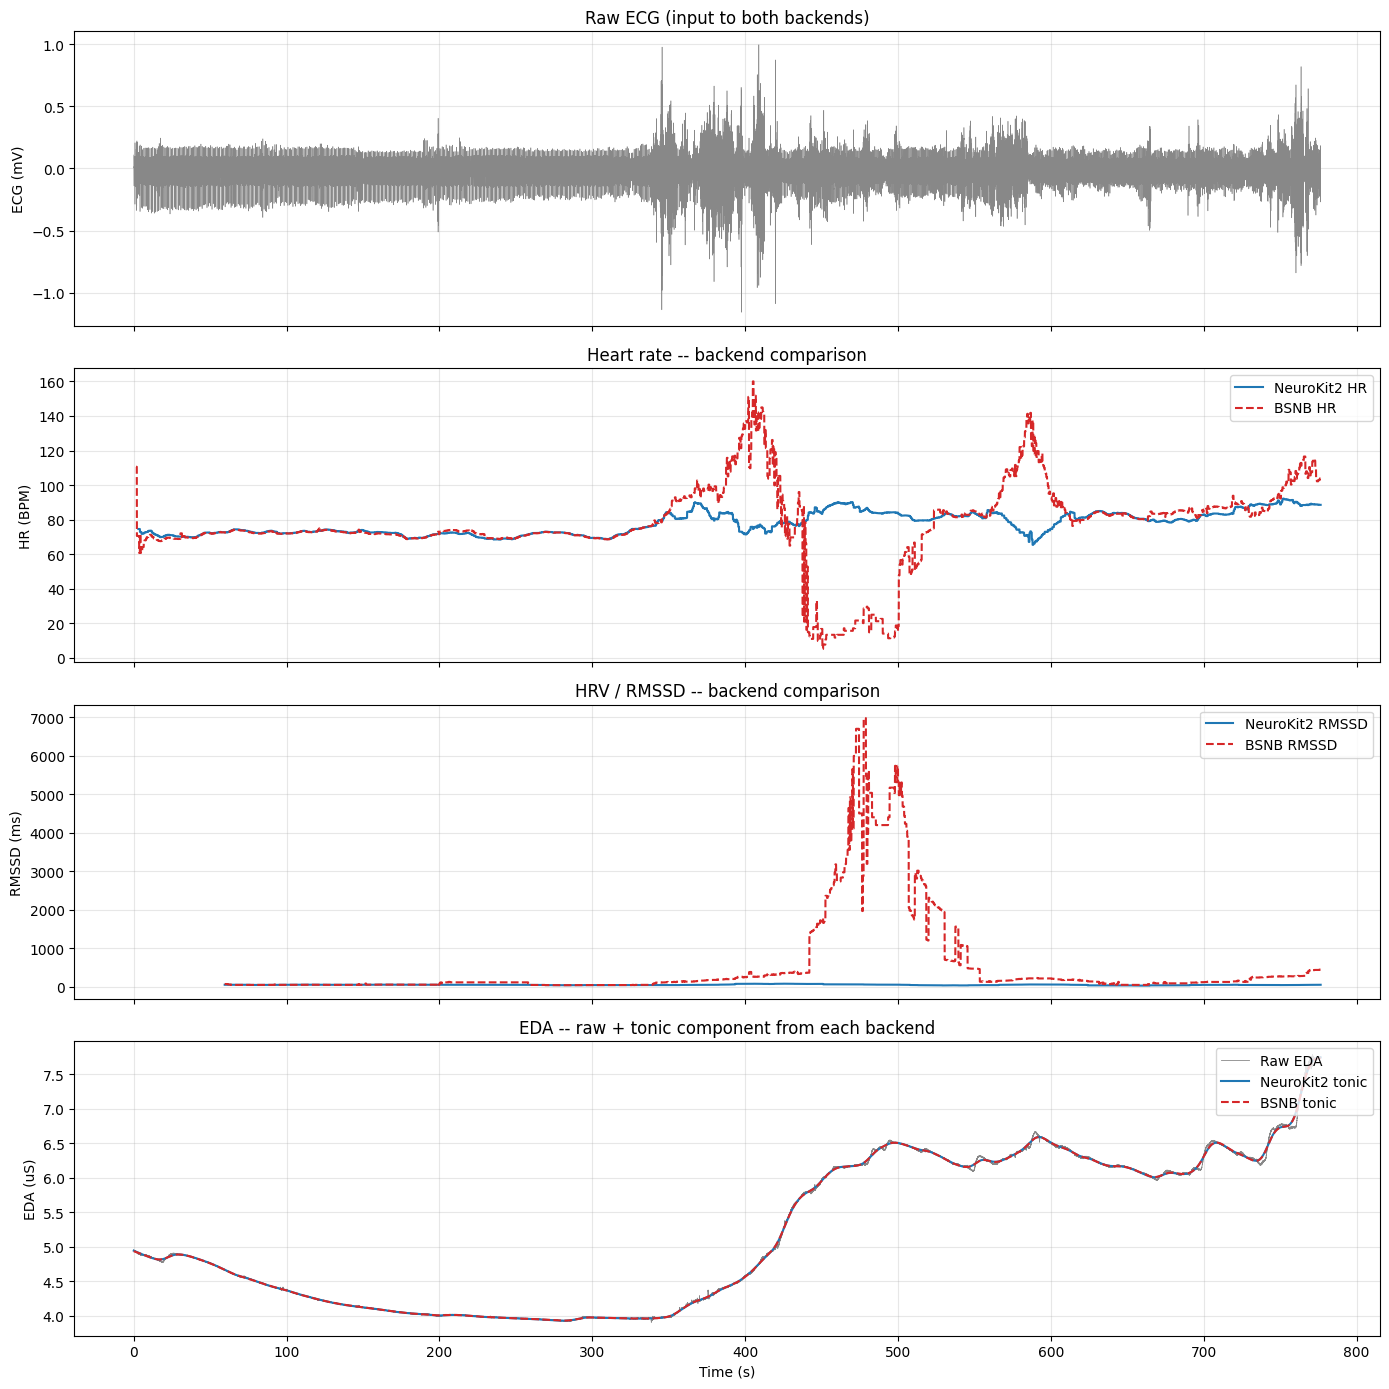

In [5]:
fig, axs = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
axs[0].plot(t, ecg_mV, color='#888', linewidth=0.4, label='Raw ECG')
axs[0].set_ylabel('ECG (mV)')
axs[0].set_title('Raw ECG (input to both backends)')
axs[0].grid(alpha=0.3)

axs[1].plot(t, hr_nk, color='#1f77b4', linewidth=1.5, label='NeuroKit2 HR')
axs[1].plot(t, hr_bs, color='#d62728', linewidth=1.5, linestyle='--', label='BSNB HR')
axs[1].set_ylabel('HR (BPM)')
axs[1].set_title('Heart rate -- backend comparison')
axs[1].legend(loc='upper right')
axs[1].grid(alpha=0.3)

axs[2].plot(t, hrv_nk, color='#1f77b4', linewidth=1.5, label='NeuroKit2 RMSSD')
axs[2].plot(t, hrv_bs, color='#d62728', linewidth=1.5, linestyle='--', label='BSNB RMSSD')
axs[2].set_ylabel('RMSSD (ms)')
axs[2].set_title('HRV / RMSSD -- backend comparison')
axs[2].legend(loc='upper right')
axs[2].grid(alpha=0.3)

axs[3].plot(t, eda_uS,    color='#888', linewidth=0.6, label='Raw EDA')
axs[3].plot(t, tonic_nk,  color='#1f77b4', linewidth=1.5, label='NeuroKit2 tonic')
axs[3].plot(t, tonic_bs,  color='#d62728', linewidth=1.5, linestyle='--', label='BSNB tonic')
axs[3].set_ylabel('EDA (uS)')
axs[3].set_xlabel('Time (s)')
axs[3].set_title('EDA -- raw + tonic component from each backend')
axs[3].legend(loc='upper right')
axs[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

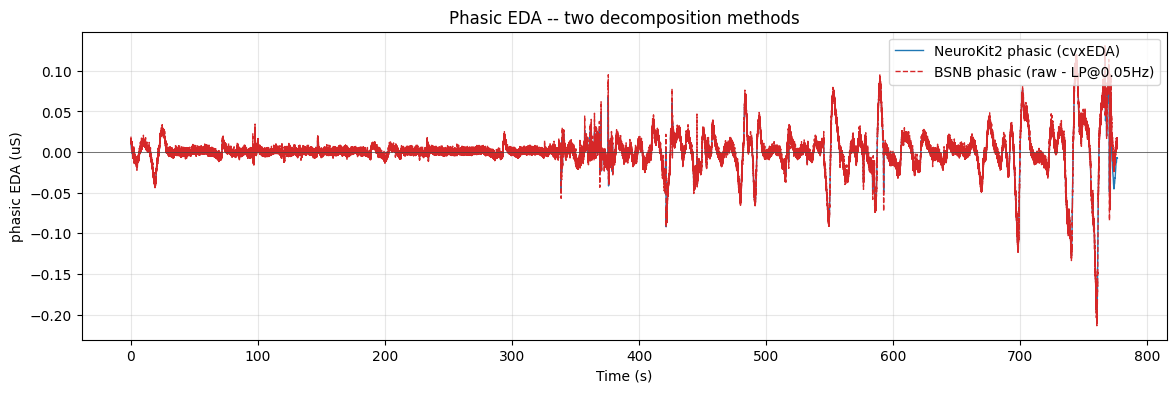

In [6]:
# Phasic-only zoom
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(t, phasic_nk, color='#1f77b4', linewidth=1.0, label='NeuroKit2 phasic (cvxEDA)')
ax.plot(t, phasic_bs, color='#d62728', linewidth=1.0, linestyle='--', label='BSNB phasic (raw - LP@0.05Hz)')
ax.axhline(0, color='#444', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('phasic EDA (uS)')
ax.set_title('Phasic EDA -- two decomposition methods')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.show()

## 4. Agreement metrics

How similar are the two backends, signal-by-signal? Pearson correlation + RMSE over the windows where BOTH backends produced a valid value.

In [7]:
def agreement(a, b, label):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 10:
        print(f'{label:10s}  too few valid samples')
        return
    aa, bb = a[mask], b[mask]
    r = float(np.corrcoef(aa, bb)[0, 1])
    rmse = float(np.sqrt(np.mean((aa - bb) ** 2)))
    bias = float(np.mean(aa - bb))
    print(f'{label:10s}  n={mask.sum():>6d}  r={r:+.3f}  '
          f'RMSE={rmse:6.3f}  bias(nk - bsnb)={bias:+6.3f}')

agreement(hr_nk,     hr_bs,     'HR')
agreement(hrv_nk,    hrv_bs,    'RMSSD')
agreement(phasic_nk, phasic_bs, 'phasic-EDA')
agreement(tonic_nk,  tonic_bs,  'tonic-EDA')

HR          n=154710  r=-0.066  RMSE=24.736  bias(nk - bsnb)=+0.679
RMSSD       n=143410  r=+0.193  RMSE=1296.064  bias(nk - bsnb)=-502.565
phasic-EDA  n=155310  r=+0.987  RMSE= 0.004  bias(nk - bsnb)=-0.000
tonic-EDA   n=155310  r=+1.000  RMSE= 0.002  bias(nk - bsnb)=+0.000


## 5. Stress-index comparison

Same fusion math (`0.5 * normEDA + 0.3 * normHRV + 0.2 * normHR`, 1-second rolling smoothing, Moldoveanu 2023 -- this is the prof's recipe in `DataAnalyze.py`), fed by the two different HR / HRV / EDA streams.

In [8]:
def moldoveanu_stress(eda, hr, hrv, baseline_sec=120.0, fs=fs):
    """Per DataAnalyze.py exactly: baseline = first baseline_sec, then
    percent-change deltas (HRV inverted), weights 0.5/0.3/0.2, smooth."""
    n = len(eda)
    bn = int(baseline_sec * fs)
    # Use only the segment where HR + HRV are valid for baseline averaging
    bmask = np.isfinite(hr) & np.isfinite(hrv)
    bmask[bn:] = False
    avg_eda = float(np.nanmean(eda[bmask])) if bmask.any() else float(np.nanmean(eda))
    avg_hr  = float(np.nanmean(hr[bmask]))  if bmask.any() else float(np.nanmean(hr))
    avg_hrv = float(np.nanmean(hrv[bmask])) if bmask.any() else float(np.nanmean(hrv))
    norm_eda = (eda - avg_eda) / max(avg_eda, 1e-9) * 100
    norm_hrv = (avg_hrv - hrv) / max(avg_hrv, 1e-9) * 100   # inverted
    norm_hr  = (hr - avg_hr)   / max(avg_hr,  1e-9) * 100
    s_inst = 0.5 * norm_eda + 0.3 * norm_hrv + 0.2 * norm_hr
    # 1-second rolling mean
    w = max(1, int(fs))
    s_t = pd.Series(s_inst).rolling(w, min_periods=1).mean().to_numpy()
    return s_t, (avg_eda, avg_hr, avg_hrv)

s_nk, base_nk = moldoveanu_stress(eda_uS, hr_nk, hrv_nk)
s_bs, base_bs = moldoveanu_stress(eda_uS, hr_bs, hrv_bs)
print(f'NeuroKit baseline avgs (EDA, HR, HRV): {tuple(round(x,2) for x in base_nk)}')
print(f'BSNB     baseline avgs (EDA, HR, HRV): {tuple(round(x,2) for x in base_bs)}')

agreement(s_nk, s_bs, 'stress')

NeuroKit baseline avgs (EDA, HR, HRV): (4.44, 73.01, 43.91)
BSNB     baseline avgs (EDA, HR, HRV): (4.44, 72.79, 44.49)
stress      n=143410  r=-0.244  RMSE=874.028  bias(nk - bsnb)=+338.416


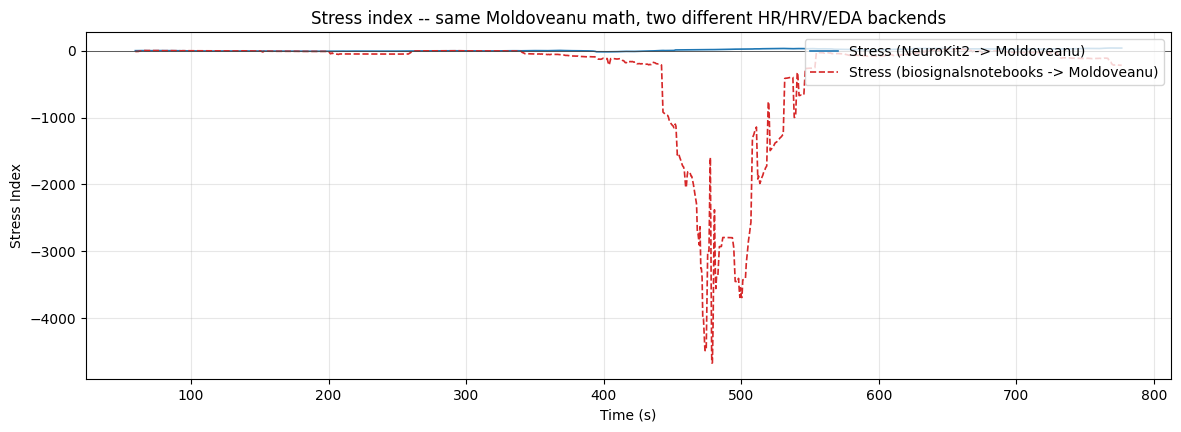

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4.5))
ax.plot(t, s_nk, color='#1f77b4', linewidth=1.2, label='Stress (NeuroKit2 -> Moldoveanu)')
ax.plot(t, s_bs, color='#d62728', linewidth=1.2, linestyle='--',
        label='Stress (biosignalsnotebooks -> Moldoveanu)')
ax.axhline(0, color='#444', linewidth=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Stress Index')
ax.set_title('Stress index -- same Moldoveanu math, two different HR/HRV/EDA backends')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.show()